In [1]:
import json
import re
import json
import matplotlib.pyplot as plt
import numpy as np
import sys
from pathlib import Path
from sklearn.metrics import accuracy_score, classification_report
from tqdm import tqdm

import pandas as pd

sys.path.append('..')
from world.world import World

output_dir = Path("../output")

model_mapping = {
    "qwen2.5-vl-3b": "Qwen2.5-VL-3B",
    "qwen2.5-vl-7b": "Qwen2.5-VL-7B",
    "llava-onevision-8b": "LLaVA OneVision 8B",
    "internvl3_5-8b": "InternVL3.5 8B",
}

exp_mapping = {
    "id": "ID",
    "ood": "OOD",
    "1_distractors": "1 Distractor",
    "9_distractors": "9 Distractors",
}


## Counting with Coordinates

In [2]:
experiment_name = "ood"

# load data
with open(f"../data/{experiment_name}/repr.json") as f:
    repr = json.load(f)

In [3]:
model_name = "internvl3_5-8b" # change the model to evaluate
    
with open(output_dir / model_name / "PtC" / experiment_name / "results.json") as f:
    results = json.load(f)

In [4]:
y_true = []
y_pred = []
for img_id, entities in results.items():
    for ent_type, question_types in entities.items():
        for q_type, res in question_types.items():
            # extract coordinate pairs like "(x, y)" from the model answer
            matches = re.findall(r'\(\s*(-?\d+)\s*,\s*(-?\d+)\s*\)', res['original_pred'])
            pred_coords = [(int(x), int(y)) for x, y in matches]

            y_true.append(res["target"])
            y_pred.append(len(pred_coords))

print(classification_report(y_true, y_pred, labels=range(10, 19)))

              precision    recall  f1-score   support

          10       1.00      1.00      1.00      1944
          11       1.00      0.99      0.99      1944
          12       0.99      0.99      0.99      1944
          13       1.00      0.99      0.99      1944
          14       0.99      0.98      0.99      1944
          15       0.98      0.97      0.98      1944
          16       0.97      0.96      0.97      1944
          17       0.96      0.97      0.97      1944
          18       0.98      0.97      0.97      1944

   micro avg       0.99      0.98      0.98     17496
   macro avg       0.99      0.98      0.98     17496
weighted avg       0.99      0.98      0.98     17496



In [5]:
import json

with open(output_dir / model_name / "PtC" / experiment_name / "pointing_classification_report.json", "w") as f:
    report = classification_report(y_true, y_pred, labels=range(10, 19), output_dict=True)
    report['accuracy'] = accuracy_score(y_true, y_pred) # type: ignore
    json.dump(report, f, indent=4)

## Grounding Quality

### Consistency, EM, and F1-Score

In [6]:
data_folder = Path("../data")


model_res = []
for experiment_name in ["id", "ood", "noisy_ts/9_distractors"]:

    with open(data_folder / experiment_name / "repr.json", "r") as f:
        repr = json.load(f)

    experiment_name = experiment_name.replace("noisy_ts/", "")
        
    for model_name in model_mapping.keys():
        with open(
            output_dir / model_name / "PtC" / experiment_name / "results.json"
        ) as f:
            results = json.load(f)

        gt_coords = 0
        correct_coords = 0
        predicted_coords = 0
        total = 0
        exact_matches = 0
        consistency = 0
        for img_id, entities in results.items():
            world = World.from_repr(repr[img_id])
            ent_coords = set()
            for repr_ent_id in world.ents:
                if repr_ent_id != "w" and not repr_ent_id.startswith("d"):
                    ent = world.ents[repr_ent_id]  # type: ignore
                    ent_coords.add(ent.position)
            
            gt_coords += len(ent_coords)

            for ent_type, question_types in entities.items():
                for q_type, res in question_types.items():
                    total += 1

                    full_pred = res['original_pred'].split("Answer:")[0].strip()
                    full_pred = full_pred[:-1] if full_pred.endswith(".") else full_pred
                    full_pred = full_pred.split("Coordinates:")[-1].strip()

                    # extract coordinate pairs like "(x, y)" from the model answer
                    matches = re.findall(r'\(\s*(-?\d+)\s*,\s*(-?\d+)\s*\)', res['original_pred'])
                    pred_coords = [(int(x), int(y)) for x, y in matches]
                    predicted_coords += len(pred_coords)

                    if set(pred_coords) == ent_coords:
                        exact_matches += 1

                    try:
                        if len(pred_coords) == int(res['original_pred'].split("Answer:")[-1].strip()):
                            consistency += 1
                    except (ValueError, IndexError):
                        pass

                    for pc in pred_coords:
                        if pc in ent_coords:
                            ent_coords.remove(pc)
                            correct_coords += 1

        precision = correct_coords / predicted_coords if predicted_coords > 0 else 0.0
        recall = correct_coords / gt_coords if gt_coords > 0 else 0.0
        f1_score = 2 * precision * recall / (precision + recall) if precision > 0 and recall > 0 else 0.0
        model_res.append({
            "model": model_mapping.get(model_name, model_name),
            "experiment": exp_mapping.get(experiment_name, experiment_name),
            "recall": recall,
            "precision": precision,
            "f1-score": f1_score,
            "exact_matches": exact_matches / total if total > 0 else 0.0,
            "consistency": consistency / total if total > 0 else 0.0
        })


In [7]:
df = pd.DataFrame(model_res)
df

,model,experiment,recall,precision,f1-score,exact_matches,consistency
0,Qwen2.5-VL-3B,ID,0.999097,0.999200,0.999148,0.995885,1.000000
1,Qwen2.5-VL-7B,ID,0.998834,0.999028,0.998931,0.995542,1.000000
2,LLaVA OneVision 8B,ID,0.994947,0.995357,0.995152,0.983139,0.999829
3,InternVL3.5 8B,ID,1.000000,1.000000,1.000000,1.000000,1.000000
4,Qwen2.5-VL-3B,OOD,0.939896,0.950592,0.945214,0.760688,0.205590
5,Qwen2.5-VL-7B,OOD,0.985372,0.986472,0.985922,0.880544,0.487883
6,LLaVA OneVision 8B,OOD,0.966437,0.971813,0.969118,0.808871,0.777206
7,InternVL3.5 8B,OOD,0.999653,0.998218,0.998935,0.980624,0.992684
8,Qwen2.5-VL-3B,9 Distractors,0.925902,0.946076,0.935880,0.697561,0.995587
9,Qwen2.5-VL-7B,9 Distractors,0.988271,0.995570,0.991907,0.957695,0.997495


### Cell-Level F1-Score

Experiments:   0%|          | 0/3 [00:00<?, ?it/s]

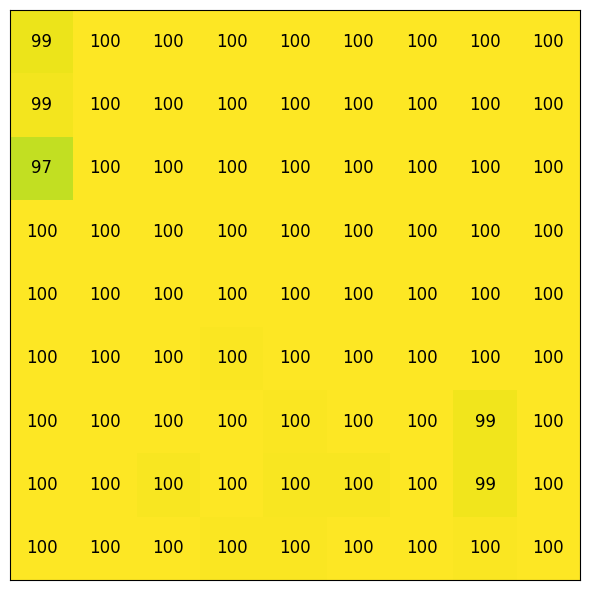

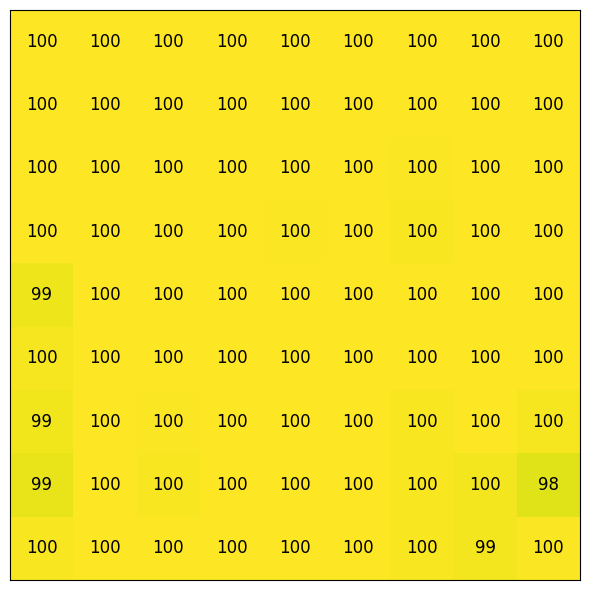

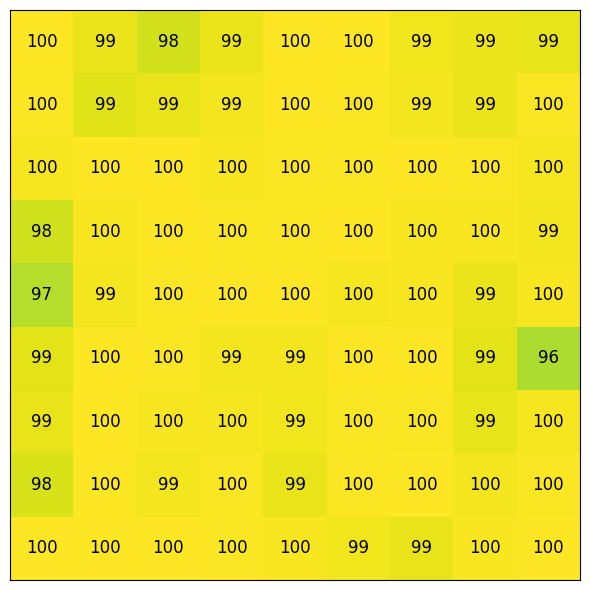

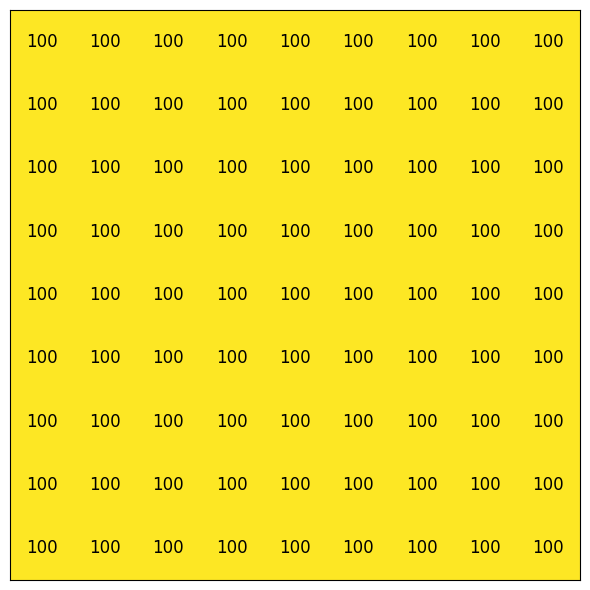

Experiments:  33%|███▎      | 1/3 [00:11<00:23, 11.58s/it]

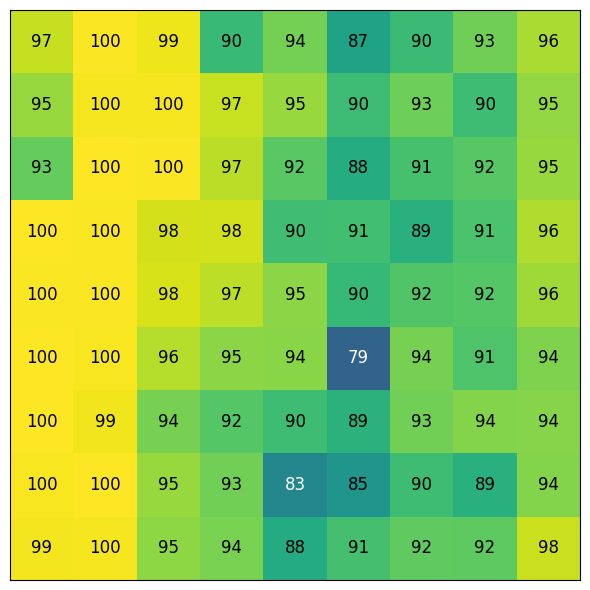

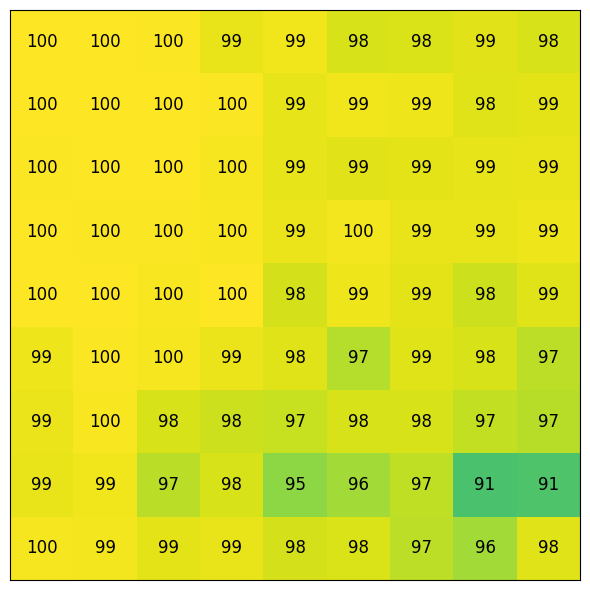

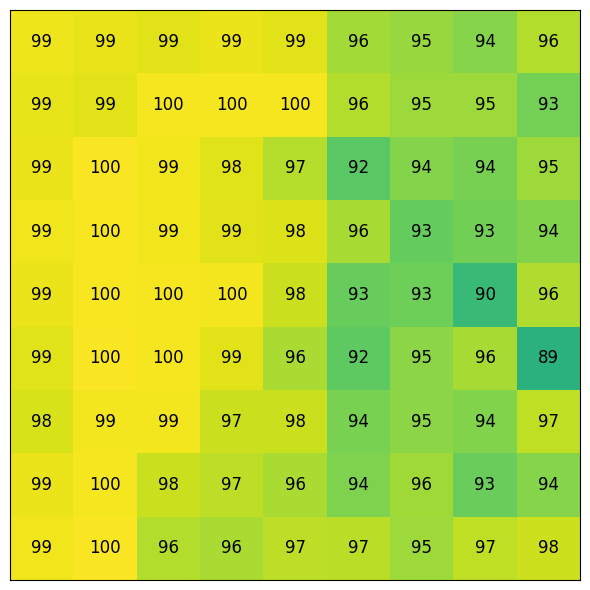

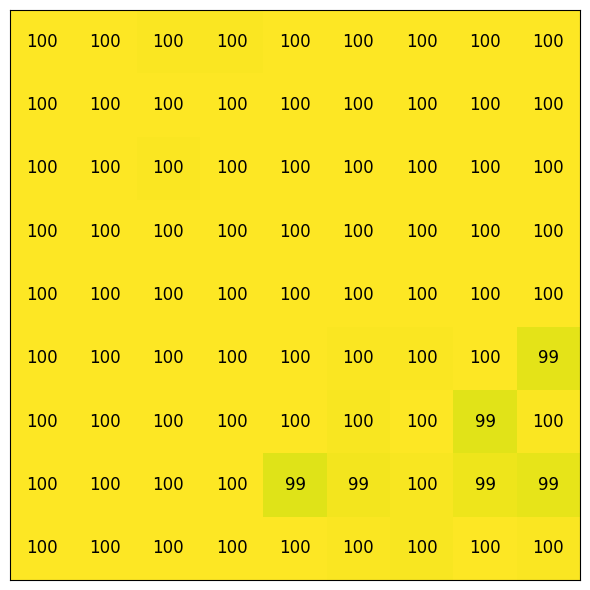

Experiments:  67%|██████▋   | 2/3 [00:55<00:30, 30.43s/it]

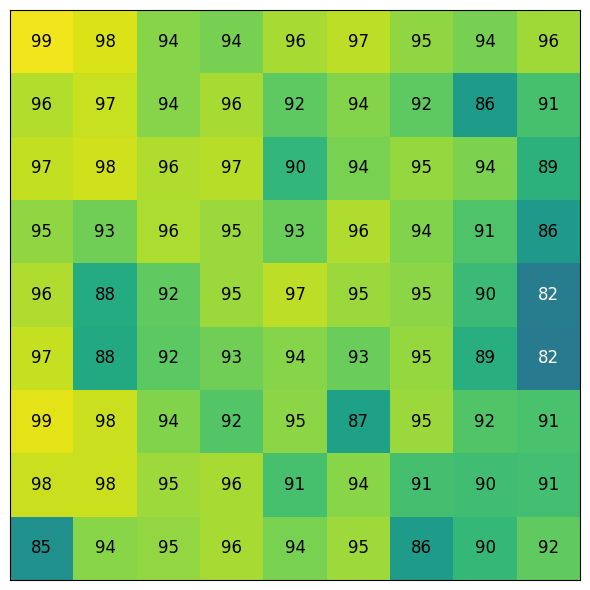

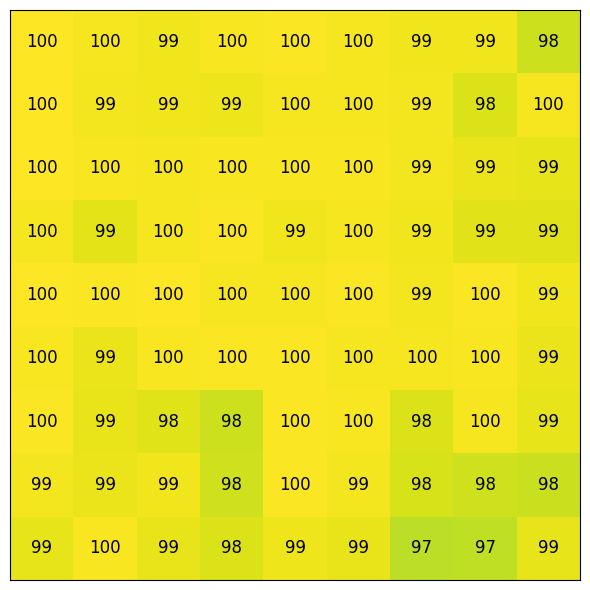

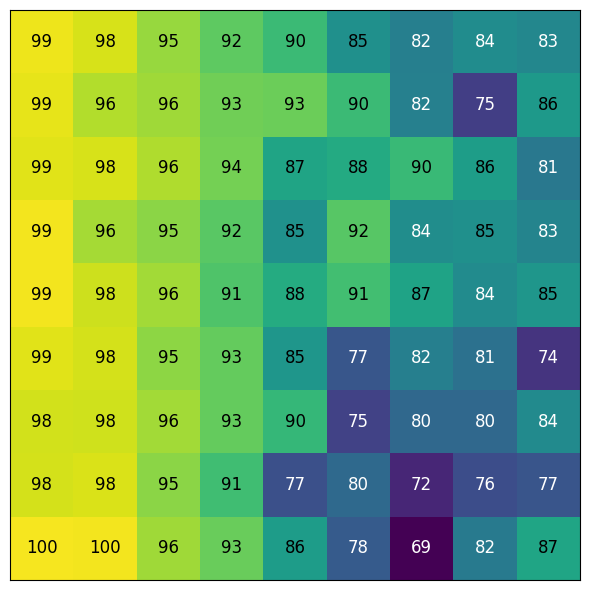

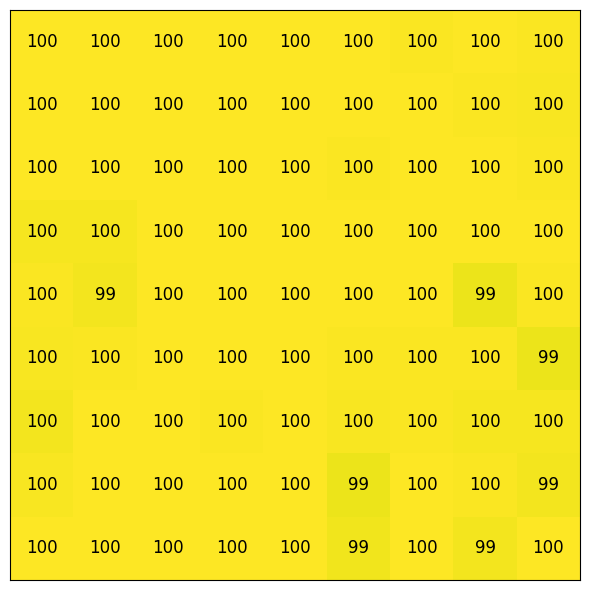

Experiments: 100%|██████████| 3/3 [02:39<00:00, 53.31s/it]


In [8]:
for experiment_name in tqdm(
    ["id", "ood", "noisy_ts/9_distractors"],
    desc="Experiments",
):

    with open("../data/" + experiment_name + "/repr.json") as f:
        repr = json.load(f)

    experiment_name = experiment_name.replace("noisy_ts/", "")
    for model_name in tqdm(model_mapping.keys(), desc="Models"):
        results_folder = output_dir / model_name / "PtC" / experiment_name
        with open(results_folder / "results.json") as f:
            results = json.load(f)

        gts = np.zeros((9, 9), dtype=int)
        positive_preds = np.zeros((9, 9), dtype=int)
        total_preds = np.zeros((9, 9), dtype=int)
        out_of_bounds = 0

        for img_id, entities in results.items():
            world = World.from_repr(repr[img_id])
            ent_coords = set()
            for repr_ent_id in world.ents:
                if repr_ent_id != "w" and not repr_ent_id.startswith("d"):
                    ent = world.ents[repr_ent_id]  # type: ignore
                    ent_coords.add(ent.position)
                    y, x = ent.position
                    gts[x, y] += 1
            for ent_type, question_types in entities.items():
                for q_type, res in question_types.items():
                    # extract coordinate pairs like "(x, y)" from the model answer
                    matches = re.findall(
                        r"\(\s*(-?\d+)\s*,\s*(-?\d+)\s*\)", res["original_pred"]
                    )
                    pred_coords = [(int(x), int(y)) for x, y in matches]

                    for pc in pred_coords:
                        y, x = pc
                        if pc in ent_coords:
                            ent_coords.remove(pc)
                            positive_preds[x, y] += 1

                        try:
                            total_preds[x, y] += 1
                        except IndexError:
                            out_of_bounds += 1

        with open(results_folder / "out_of_bounds.json", "w") as f:
            json.dump({"OOB (%)": f"{out_of_bounds / total_preds.sum() * 100:.2f}%"}, f)

        precision = np.divide(
            positive_preds,
            total_preds,
            out=np.zeros_like(positive_preds, dtype=float),
            where=total_preds != 0,
        )
        recall = np.divide(
            positive_preds,
            gts,
            out=np.zeros_like(positive_preds, dtype=float),
            where=gts != 0,
        )
        f1_score = np.divide(
            2 * precision * recall,
            precision + recall,
            out=np.zeros_like(precision, dtype=float),
            where=(precision + recall) != 0,
        )

        vmax = np.nanmax(100)
        vmin = np.nanmin(69)

        fig, ax = plt.subplots(figsize=(6, 6))
        im = ax.imshow(
            f1_score * 100.0, cmap="viridis", origin="upper", vmin=vmin, vmax=vmax
        )
        ax.set_xticks([])
        ax.set_yticks([])

        threshold = (vmax + vmin) / 2 if not (np.isnan(vmax) or np.isnan(vmin)) else 50

        for row in range(9):
            for col in range(9):
                val = f1_score[row, col] * 100.0
                txt = f"{val:.0f}" if not np.isnan(val) else "-"
                color = "black" if not np.isnan(val) and val > threshold else "white"
                ax.text(
                    col, row, txt, ha="center", va="center", fontsize=12, color=color
                )

        plt.tight_layout()
        plt.savefig(results_folder / f"f1-score_heatmap.png")
        plt.show()